# DMSO controls identification and subset selection

This notebook identifies the DMSO (negative control) wells across JUMP-CP, confirms the assumption that DMSO is scattered across most plates as positional controls, and selects a small working subset (one source, one batch, a few plates) that we will use as our dataset for the rest of the project.

Identifying DMSO wells precisely is critical for the rest of the project: Phenoseeker computes its sphering normalization from the embedding covariance of DMSO controls *within each plate*.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload metadata from the JUMP-CP datasets repo
plate_url    = "https://github.com/jump-cellpainting/datasets/raw/main/metadata/plate.csv.gz"
well_url     = "https://github.com/jump-cellpainting/datasets/raw/main/metadata/well.csv.gz"
compound_url = "https://github.com/jump-cellpainting/datasets/raw/main/metadata/compound.csv.gz"

plates    = pd.read_csv(plate_url)
wells     = pd.read_csv(well_url)
compounds = pd.read_csv(compound_url)

print(f"Loaded {len(plates):,} plates, {len(wells):,} wells, {len(compounds):,} compounds")

Loaded 2,525 plates, 1,151,808 wells, 115,796 compounds


In [ ]:
# The most common perturbation across all wells is almost certainly the negative control (DMSO)
top_perturbations = wells["Metadata_JCP2022"].value_counts().head(10)
print("Top 10 most frequent perturbation IDs across all wells:")
print(top_perturbations)

Top 10 most frequent perturbation IDs across all wells:
Metadata_JCP2022
JCP2022_033924     143581
JCP2022_999999      37094
JCP2022_UNKNOWN     16069
JCP2022_050797      10313
JCP2022_037716      10152
JCP2022_012818      10125
JCP2022_025848      10093
JCP2022_046054      10087
JCP2022_064022       9927
JCP2022_085227       9504
Name: count, dtype: int64


In [ ]:
# Look up the most frequent ID in the compound metadata
top_pert_id = top_perturbations.index[0]
print(f"Most frequent perturbation ID: {top_pert_id}")
print()

candidate = compounds[compounds["Metadata_JCP2022"] == top_pert_id]
print("Lookup in the compound table:")
candidate

Most frequent perturbation ID: JCP2022_033924

Lookup in the compound table:


,Metadata_JCP2022,Metadata_InChIKey,Metadata_InChI,Metadata_SMILES
33641,JCP2022_033924,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,InChI=1S/C2H6OS/c1-4(2)3/h1-2H3,C[S+](C)[O-]


In [ ]:
# Define DMSO_ID for the rest of the notebook
DMSO_ID = top_pert_id
print(f"Using {DMSO_ID} as the DMSO identifier for downstream analyses.")

Using JCP2022_033924 as the DMSO identifier for downstream analyses.


In [ ]:
dmso_per_plate = (
    wells[wells["Metadata_JCP2022"] == DMSO_ID]
    .groupby(["Metadata_Source", "Metadata_Plate"])
    .size()
    .reset_index(name="n_dmso_wells")
)

print(f"Number of plates containing at least one DMSO well: {len(dmso_per_plate):,}")
print()
print("Statistics on DMSO well count per plate:")
dmso_per_plate["n_dmso_wells"].describe()

Number of plates containing at least one DMSO well: 2,255

Statistics on DMSO well count per plate:


,n_dmso_wells
count,2255.000000
mean,63.672284
std,104.696322
min,8.000000
25%,32.000000
50%,32.000000
75%,32.000000
max,1408.000000


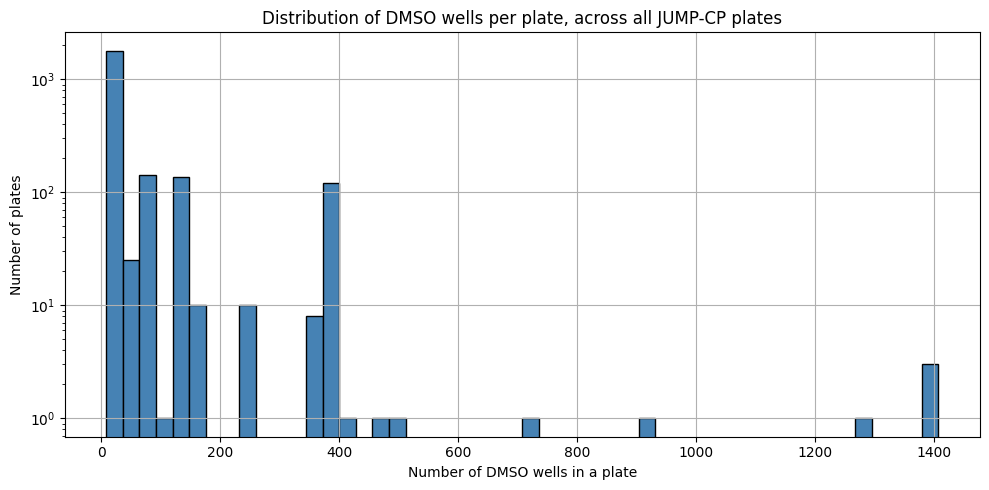

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
dmso_per_plate["n_dmso_wells"].hist(bins=50, ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribution of DMSO wells per plate, across all JUMP-CP plates")
ax.set_xlabel("Number of DMSO wells in a plate")
ax.set_ylabel("Number of plates")
ax.set_yscale("log")  # log scale because we expect a bimodal distribution
plt.tight_layout()
plt.show()

In [ ]:
# Merge DMSO counts with plate type
dmso_by_type = dmso_per_plate.merge(
    plates[["Metadata_Source", "Metadata_Plate", "Metadata_PlateType"]],
    on=["Metadata_Source", "Metadata_Plate"]
)

print("DMSO wells per plate, broken down by plate type:")
dmso_by_type.groupby("Metadata_PlateType")["n_dmso_wells"].agg(["count", "mean", "median", "min", "max"]).round(1)

DMSO wells per plate, broken down by plate type:


,count,mean,median,min,max
Metadata_PlateType,,,,,
COMPOUND,1872,49.8,32.0,11,928
COMPOUND_EMPTY,20,429.5,352.0,32,1408
CRISPR,141,8.0,8.0,8,8
DMSO,77,384.0,384.0,383,384
TARGET1,4,64.0,64.0,64,64
TARGET2,141,76.7,64.0,64,256


In [ ]:
# Pick a source with reasonable COMPOUND plate count
plates_compound = plates[plates["Metadata_PlateType"] == "COMPOUND"]
print("COMPOUND plates per source:")
print(plates_compound.groupby("Metadata_Source").size().sort_values(ascending=False))

# Choose source_3 (the source with the most COMPOUND plates)
SUBSET_SOURCE = "source_3"

# Pick one batch from this source (the first one, alphabetically)
source_plates = plates_compound[plates_compound["Metadata_Source"] == SUBSET_SOURCE]
SUBSET_BATCH = sorted(source_plates["Metadata_Batch"].unique())[0]
print(f"Selected: source = {SUBSET_SOURCE}, batch = {SUBSET_BATCH}")

# Pick the first 3 COMPOUND plates of this batch
batch_plates = source_plates[source_plates["Metadata_Batch"] == SUBSET_BATCH]
SUBSET_PLATES = sorted(batch_plates["Metadata_Plate"].tolist())[:3]
print(f"Selected plates ({len(SUBSET_PLATES)}): {SUBSET_PLATES}")

# Summary of the selected subset
subset_wells = wells[
    (wells["Metadata_Source"] == SUBSET_SOURCE) &
    (wells["Metadata_Plate"].isin(SUBSET_PLATES))
]
n_dmso = (subset_wells["Metadata_JCP2022"] == DMSO_ID).sum()
n_compounds = subset_wells["Metadata_JCP2022"].nunique() - 1  # minus the DMSO ID

print(f"Subset summary:")
print(f"  Source:    {SUBSET_SOURCE}")
print(f"  Batch:     {SUBSET_BATCH}")
print(f"  Plates:    {len(SUBSET_PLATES)}")
print(f"  Wells:     {len(subset_wells)}")
print(f"  DMSO:      {n_dmso} wells")
print(f"  Compounds: {n_compounds} unique non-DMSO perturbations")

COMPOUND plates per source:
Metadata_Source
source_3     237
source_6     225
source_2     219
source_10    208
source_8     199
source_5     197
source_11    173
source_15    147
source_7     121
source_9      99
source_1      51
dtype: int64
Selected: source = source_3, batch = CP59
Selected plates (3): ['BR5867a3', 'BR5867b3', 'BR5867c3']
Subset summary:
  Source:    source_3
  Batch:     CP59
  Plates:    3
  Wells:     1152
  DMSO:      96 wells
  Compounds: 816 unique non-DMSO perturbations


In [ ]:
# Are the 3 plates actual replicates of each other?
subset_wells = wells[
    (wells["Metadata_Source"] == SUBSET_SOURCE) &
    (wells["Metadata_Plate"].isin(SUBSET_PLATES))
]

# Drop DMSO to focus on the actual compound perturbations
subset_non_dmso = subset_wells[subset_wells["Metadata_JCP2022"] != DMSO_ID]

print("Unique non-DMSO compounds per plate:")
for plate in SUBSET_PLATES:
    n = subset_non_dmso[subset_non_dmso["Metadata_Plate"] == plate]["Metadata_JCP2022"].nunique()
    print(f"  {plate}: {n} unique compounds")
print()

# Compute pairwise overlaps
plate_compound_sets = {
    plate: set(subset_non_dmso[subset_non_dmso["Metadata_Plate"] == plate]["Metadata_JCP2022"])
    for plate in SUBSET_PLATES
}

common_all = set.intersection(*plate_compound_sets.values())
union_all = set.union(*plate_compound_sets.values())

print(f"Compounds present in ALL 3 plates: {len(common_all)}")
print(f"Total unique compounds across the 3 plates (union): {len(union_all)}")
print(f"Overlap ratio (common / union): {len(common_all) / len(union_all):.2%}")

Unique non-DMSO compounds per plate:
  BR5867a3: 303 unique compounds
  BR5867b3: 286 unique compounds
  BR5867c3: 289 unique compounds

Compounds present in ALL 3 plates: 14
Total unique compounds across the 3 plates (union): 816
Overlap ratio (common / union): 1.72%


In [ ]:
# Identify the 14 reference compounds shared across all 3 plates
shared_compounds_ids = set.intersection(*plate_compound_sets.values())

shared_info = compounds[compounds["Metadata_JCP2022"].isin(shared_compounds_ids)]
print(f"The {len(shared_compounds_ids)} reference compounds present in all 3 plates:")
shared_info[["Metadata_JCP2022", "Metadata_InChIKey", "Metadata_SMILES"]]

The 14 reference compounds present in all 3 plates:


,Metadata_JCP2022,Metadata_InChIKey,Metadata_SMILES
12705,JCP2022_012818,CQKBSRPVZZLCJE-UHFFFAOYSA-N,COc1ncc2cc(C(=O)Nc3cc(C(=O)NCc4cccc(Cl)c4)ccc3...
25628,JCP2022_025848,GJFCONYVAUNLKB-UHFFFAOYSA-N,CC1CC2C3CC=C4CC(=O)C=CC4(C)C3(F)C(O)CC2(C)C1(O...
34802,JCP2022_035095,IHLVSLOZUHKNMQ-UHFFFAOYSA-N,c1ccc(-c2nn3c(c2-c2ccnc4cc(OCCN5CCOCC5)ccc24)C...
37405,JCP2022_037716,IVUGFMLRJOCGAS-UHFFFAOYSA-N,Cc1csc(-c2n[nH]c(=Nc3ccc(Oc4ncccc4-c4cc[nH]c(=...
39986,JCP2022_040317,JKBUWWDIIROVRV-UHFFFAOYSA-N,O=C(COc1ccc2ccccc2c1)N1CCN(c2ccccc2O)CC1
45680,JCP2022_046054,KPBNHDGDUADAGP-UHFFFAOYSA-N,O=C(C=Cc1cccnc1)NCCCCC1CCN(C(=O)c2ccccc2)CC1
50393,JCP2022_050797,LOUPRKONTZGTKE-UHFFFAOYSA-N,C=CC1CN2CCC1CC2C(O)c1ccnc2ccc(OC)cc12
60968,JCP2022_061459,NUOJETVSCSIFPX-UHFFFAOYSA-N,O=[N+]([O-])c1ccc(S(=O)(=O)Oc2ccc(-c3cnc4ccccc...
63508,JCP2022_064022,OINGHOPGNMYCAB-UHFFFAOYSA-N,CC(C)NC(=O)N1CCC(N=C2Nc3cc(F)ccc3N(CC(F)F)c3cc...
70790,JCP2022_071377,PWFKBCNVKFIJGN-UHFFFAOYSA-N,Cc1cccc(=NC(=O)COc2ccc(Br)cc2)[nH]1


## Summary

### What I learned about DMSO in JUMP-CP

I started by looking for the most frequent perturbation across all 1,151,808 wells in JUMP-CP. The top one is `JCP2022_033924`, which appears in 143,581 wells, more than three times more than the next most frequent. Looking it up in the compound table confirmed that this is dimethyl sulfoxide (DMSO), the standard solvent used in chemical screening:

- InChIKey: `IAZDPXIOMUYVGZ-UHFFFAOYSA-N`
- SMILES: `C[S+](C)[O-]` (zwitterionic notation, equivalent to `CS(C)=O`)

In a high-content screen, DMSO is used as a negative control: wells filled only with DMSO contain cells that have not been treated with any active compound, and serve as a baseline against which compound-treated wells can be compared.

### How DMSO controls are spread across the dataset

JUMP-CP contains 2,525 plates in total. Of these, 2,255 carry at least one DMSO well, which leaves 270 plates with no DMSO at all. Most of these are the ORF plates (gene overexpression plates, 251 of them) plus a few positive-control plates (POSCON8); these probably use different reference conditions instead of DMSO.

On the plates that do contain DMSO, the number of DMSO wells per plate varies a lot. The median is 32, but the maximum reaches 1,408. The histogram is clearly bimodal:

- A main peak around 32 DMSO wells per plate. This is about 8 percent of the 384 wells of a standard plate, which corresponds to the typical layout of compound-screening plates: a small number of DMSO wells scattered across the plate as positional controls.
- A second cluster around 384 DMSO wells per plate, corresponding to the 77 dedicated DMSO plates where the entire plate is DMSO and serves as a calibration plate.
- A long tail of unusual cases, especially the COMPOUND_EMPTY plates where unused compound positions were filled with DMSO instead, sometimes reaching up to 1,408 DMSO wells when several such plates are grouped together.

Breaking the distribution down by plate type confirms the structure:

| Plate type     | Number of plates with DMSO | Median DMSO wells per plate |
|:---------------|:--------------------------:|:---------------------------:|
| COMPOUND       | 1,872                      | 32                          |
| COMPOUND_EMPTY | 20                         | 352                         |
| CRISPR         | 141                        | 8 (always exactly)          |
| DMSO           | 77                         | 384 (whole plate)           |
| TARGET1        | 4                          | 64                          |
| TARGET2        | 141                        | 64                          |

The important finding for the rest of the project is that COMPOUND plates consistently carry about 32 DMSO wells. The Phenoseeker pipeline computes a per-plate normalization (called sphering) using the DMSO wells of each plate as a reference, and 32 wells per plate is enough to estimate this normalization with reasonable statistical stability.

### Choosing a small subset to work with

To build a small but representative working subset, I picked the source with the most COMPOUND plates, which is `source_3` with 237 such plates. Within source_3 I chose the first batch alphabetically, `CP59`, and within that batch the first three COMPOUND plates: `BR5867a3`, `BR5867b3`, `BR5867c3`.

This gives:

- 3 plates from the same batch
- 1,152 wells in total (three plates of 384 wells each)
- 96 DMSO wells in total (32 per plate, matching the dataset median)
- 816 unique non-DMSO compound perturbations

### Are the 3 plates replicates of each other?

I expected the three plates to be replicates of the same compound layout, but after checking that turned out to be wrong. The three plates are essentially **different plates that share only a small reference set**:

- `BR5867a3` carries 303 unique compounds
- `BR5867b3` carries 286 unique compounds
- `BR5867c3` carries 289 unique compounds
- Only 14 entries are present on all three plates (and one of them is a placeholder, see below)
- About 48 additional compounds appear on exactly two of the three plates
- The remaining 754 or so compounds appear on only one plate

Two additional details about the internal layout of each plate:

- Each plate has 384 wells in total, minus 32 DMSO wells, which leaves 352 wells for compounds. But each plate carries only around 290 unique compounds, meaning that about 50 wells per plate are duplicates of compounds already present elsewhere on the same plate. This is normal in high-content screening: some compounds are placed in multiple positions on a plate so that one can check whether wells near the edges behave the same as wells in the center.
- The handful of compounds shared across all three plates almost certainly forms a small reference panel, included to anchor the plates against each other and detect technical drift between them.

### What the 14 shared "compounds" actually are

Looking at the list of compounds present on all three plates, one stands out: `JCP2022_999999` has both its InChIKey and its SMILES set to `NaN`. So it is not a real molecule but a placeholder code. It was also the second most frequent entry in the entire JUMP-CP well table (37,094 wells overall), which is consistent with a generic role: this is most likely the code used for wells that contain no actual perturbation, such as empty wells, untreated controls, or wells excluded from analysis. So among the 14 shared entries, only 13 are real chemical compounds.

### Working subset, summarized

For the rest of the project I will work on:

- **Source**: `source_3`
- **Batch**: `CP59`
- **Plates**: `BR5867a3`, `BR5867b3`, `BR5867c3`
- **Wells**: 1,152 in total
- **DMSO wells**: 96 (32 per plate)
- **Unique real compounds**: 816 across the three plates
- **Shared reference compounds** (present on all three plates): 13 real molecules plus the `JCP2022_999999` placeholder

This subset is small enough to fit in Colab memory and to be processed quickly, but it contains every structural element of a real COMPOUND screen: scattered DMSO controls for per-plate normalization, within-plate compound duplicates for positional bias checks, and a shared reference panel for inter-plate consistency checks.
